# 🇹🇷 MossFormerGAN_SE_16K — Türkçe Fine-Tune
**FullSubNet+ ile adil karşılaştırma için aynı veri, aynı metrikler**

| | FullSubNet+ | MossFormerGAN_SE_16K |
|---|---|---|
| Mimari | LSTM + cIRM maskesi | MossFormer2 backbone + GAN |
| Sample rate | 16 kHz | 16 kHz ✅ aynı |
| Parametre | ~8.6M | ~25M |
| Veri | FLEURS 2k + CV17 12k | **aynı** ✅ |
| Noise | DNS Challenge | **aynı** ✅ |
| SNR aralığı | -5 ~ +20 dB | **aynı** ✅ |

## Neden MossFormerGAN_SE_16K?
MossFormer2_SE_48K 48 kHz çalışır — adil karşılaştırma için 16 kHz olan
MossFormerGAN_SE_16K seçildi. MossFormer2 backbone'u kullanır, GAN ile eğitilir.

In [1]:
# ============================================================
# Hücre 1 - Kurulum
# ============================================================
!nvidia-smi

!apt-get update -qq
!apt-get install -y -qq libsndfile1 ffmpeg

!pip install -q datasets soundfile librosa scipy tqdm matplotlib \
    tensorboard pesq pystoi gdown huggingface_hub

# ClearerVoice-Studio repo — resmi eğitim scriptleri burada
!rm -rf /content/ClearerVoice-Studio
!git clone --depth 1 https://github.com/modelscope/ClearerVoice-Studio.git /content/ClearerVoice-Studio

# requirements
!pip install -q -r /content/ClearerVoice-Studio/requirements.txt

print("✅ Kurulum tamamlandı")

Mon May 25 20:18:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ============================================================
# Hücre 2 - Drive mount, importlar
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

import os, sys, gc, json, random, shutil, warnings, time
from pathlib import Path
import numpy as np
import soundfile as sf
import torch
import torchaudio
from tqdm.auto import tqdm
from datasets import load_dataset, concatenate_datasets

warnings.filterwarnings("ignore")
if not hasattr(np,"complex"): np.complex = np.complex128
if not hasattr(np,"float"):   np.float = float

# ClearerVoice path
REPO = Path("/content/ClearerVoice-Studio")
TRAIN_DIR = REPO / "train/speech_enhancement"
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(TRAIN_DIR))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB")

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
# ============================================================
# Hücre 3 - Konfigürasyon
# FullSubNet+ ile AYNI veri ayarları — adil karşılaştırma
# ============================================================

CFG = {
    # Veri — FullSubNet+ ile TAM AYNI
    "n_fleurs"          : 2000,
    "n_cv"              : 12000,
    "sample_rate"       : 16000,   # MossFormerGAN_SE_16K: 16 kHz
    "min_duration_s"    : 1.0,
    "max_duration_s"    : 20.0,

    # Noise — FullSubNet+ ile TAM AYNI
    "use_dns_noise_from_drive": True,
    "dns_noise_source"  : "/content/drive/MyDrive/Denoiser/Datasets/DNS-Challenge/datasets/noise",
    "noise_files"       : 500,
    "snr_levels_db"     : [-5, 0, 5, 10, 15, 20],

    # Eğitim
    "batch_size"        : 4,    # MossFormerGAN büyük model, T4→2, A100→8
    "num_workers"       : 2,
    "max_epoch"         : 60,
    "val_split"         : 0.10,
    "sub_sample_length_s": 4.0,

    # Model (MossFormerGAN_SE_16K resmi config değerleri)
    "network"           : "MossFormerGAN_SE_16K",
    "init_learning_rate": 0.0001,  # FullSubNet+ ile aynı
    "grad_clip"         : 5.0,
    "half_lr_patience"  : 3,       # 3 epoch iyileşmezse LR yarıya
    "early_stop_patience": 6,

    # Pretrained — HuggingFace'ten otomatik indirilir
    "pretrained_model"  : "alibabasglab/MossFormerGAN_SE_16K",
    "use_pretrained"    : True,
}

# Dizinler
BASE_DIR   = Path("/content/drive/MyDrive/mossformergan_tr")
LOCAL_DIR  = Path("/content/mfgan_local")
CLEAN_DIR  = LOCAL_DIR / "clean_16k"
NOISE_DIR  = LOCAL_DIR / "dns_noise_16k"
NOISY_DIR  = LOCAL_DIR / "noisy_16k"
CKPT_DIR   = BASE_DIR / "checkpoints"
LOG_DIR    = BASE_DIR / "logs"
SAMPLE_DIR = BASE_DIR / "samples"
SCP_DIR    = LOCAL_DIR / "scp"

for d in [CLEAN_DIR, NOISE_DIR, NOISY_DIR, CKPT_DIR, LOG_DIR, SAMPLE_DIR, SCP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(json.dumps(CFG, indent=2, default=str))
print("BASE_DIR:", BASE_DIR)

{
  "n_fleurs": 2000,
  "n_cv": 12000,
  "sample_rate": 16000,
  "min_duration_s": 1.0,
  "max_duration_s": 20.0,
  "use_dns_noise_from_drive": true,
  "dns_noise_source": "/content/drive/MyDrive/Denoiser/Datasets/DNS-Challenge/datasets/noise",
  "noise_files": 500,
  "snr_levels_db": [
    -5,
    0,
    5,
    10,
    15,
    20
  ],
  "batch_size": 4,
  "num_workers": 2,
  "max_epoch": 60,
  "val_split": 0.1,
  "sub_sample_length_s": 4.0,
  "network": "MossFormerGAN_SE_16K",
  "init_learning_rate": 0.0001,
  "grad_clip": 5.0,
  "half_lr_patience": 3,
  "early_stop_patience": 6,
  "pretrained_model": "alibabasglab/MossFormerGAN_SE_16K",
  "use_pretrained": true
}
BASE_DIR: /content/drive/MyDrive/mossformergan_tr


In [5]:
# ============================================================
# Hücre 4 - Ses yardımcı fonksiyonlar
# FullSubNet+ notebook'undaki ile AYNI fonksiyonlar
# ============================================================

def to_mono_float32(audio):
    audio = np.asarray(audio, dtype=np.float32)
    if audio.ndim > 1: audio = audio.mean(axis=-1)
    return audio.astype(np.float32)

def peak_normalize(audio, peak_target=0.9):
    audio = to_mono_float32(audio)
    peak = np.max(np.abs(audio)) + 1e-8
    if peak < 1e-5: return None
    return (audio / peak * peak_target).astype(np.float32)

def resample_np(audio, orig_sr, target_sr):
    audio = to_mono_float32(audio)
    if orig_sr == target_sr: return audio
    t = torch.from_numpy(audio).float().unsqueeze(0)
    return torchaudio.functional.resample(t, orig_sr, target_sr).squeeze(0).numpy().astype(np.float32)

def load_hf_audio(item, target_sr):
    try:
        arr = np.array(item["audio"]["array"], dtype=np.float32)
        sr  = int(item["audio"]["sampling_rate"])
        arr = to_mono_float32(arr)
        arr = resample_np(arr, sr, target_sr)
        dur = len(arr) / target_sr
        if not (CFG["min_duration_s"] <= dur <= CFG["max_duration_s"]): return None
        return peak_normalize(arr, 0.9)
    except: return None

def load_wav_any(path, target_sr):
    audio, sr = sf.read(str(path), dtype="float32", always_2d=False)
    audio = to_mono_float32(audio)
    return resample_np(audio, sr, target_sr).astype(np.float32)

def write_wav(path, audio, sr):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), audio.astype(np.float32), sr)

print("✅ Yardımcı fonksiyonlar hazır")

✅ Yardımcı fonksiyonlar hazır


In [6]:
# ============================================================
# Hücre 5 - Pretrained MossFormerGAN_SE_16K checkpoint
# HuggingFace'ten otomatik indirir
# ============================================================
from huggingface_hub import hf_hub_download, snapshot_download
import os

PRETRAINED_DIR = CKPT_DIR / "pretrained_mossformergan"
PRETRAINED_DIR.mkdir(exist_ok=True)

def download_pretrained():
    # Checkpoint var mı?
    ckpt_files = list(PRETRAINED_DIR.glob("*.pt")) + list(PRETRAINED_DIR.glob("*.pth"))
    if ckpt_files:
        print(f"✅ Pretrained checkpoint mevcut: {ckpt_files[0]}")
        return ckpt_files[0]

    print("📥 MossFormerGAN_SE_16K pretrained indiriliyor...")
    try:
        # HuggingFace'ten tüm model dosyalarını indir
        snapshot_download(
            repo_id=CFG["pretrained_model"],
            local_dir=str(PRETRAINED_DIR),
            ignore_patterns=["*.md","*.txt"]
        )
        ckpt_files = list(PRETRAINED_DIR.glob("*.pt")) + list(PRETRAINED_DIR.glob("*.pth"))
        if ckpt_files:
            print(f"✅ İndirildi: {ckpt_files[0]}")
            return ckpt_files[0]
    except Exception as e:
        print(f"⚠️  HuggingFace indirme başarısız: {e}")
        print("use_pretrained=False ile devam edilecek")
        CFG["use_pretrained"] = False
        return None

if CFG["use_pretrained"]:
    pretrained_path = download_pretrained()
else:
    pretrained_path = None
    print("ℹ️  use_pretrained=False")

✅ Pretrained checkpoint mevcut: /content/drive/MyDrive/mossformergan_tr/checkpoints/pretrained_mossformergan/last_best_checkpoint.pt


In [7]:
# ============================================================
# Hücre 6 - DNS Noise hazırlama (FullSubNet+ ile AYNI)
# ============================================================

def generate_synthetic_noise(target_dir, n, sr):
    target_dir.mkdir(parents=True, exist_ok=True)
    start = len(sorted(target_dir.glob("*.wav")))
    for k in tqdm(range(n), desc="Sentetik gürültü"):
        i = start + k
        dur = random.uniform(3.0, 8.0)
        s   = int(dur * sr)
        c   = i % 4
        if   c == 0: noise = np.random.randn(s).astype(np.float32)
        elif c == 1:
            w = np.random.randn(s); f = np.fft.rfftfreq(s); f[0]=1.0
            noise = np.fft.irfft(np.fft.rfft(w)/np.sqrt(f),n=s).astype(np.float32)
        elif c == 2: noise = np.cumsum(np.random.randn(s)).astype(np.float32)
        else:
            from scipy import signal
            noise = np.random.randn(s).astype(np.float32)
            b,a = signal.butter(4,[200/(sr/2),3400/(sr/2)],"bandpass")
            noise = signal.lfilter(b,a,noise).astype(np.float32)
        n_arr = peak_normalize(noise, 0.8)
        if n_arr is not None:
            write_wav(target_dir/f"synth_{i:05d}.wav", n_arr, sr)

def prepare_noise():
    existing = sorted(NOISE_DIR.glob("*.wav"))
    if len(existing) >= CFG["noise_files"]:
        print(f"✅ Noise hazır: {len(existing)} dosya"); return existing[:CFG["noise_files"]]

    if CFG["use_dns_noise_from_drive"]:
        src = Path(CFG["dns_noise_source"])
        if src.exists():
            src_files = sorted(src.rglob("*.wav"))
            print(f"DNS source: {len(src_files)} dosya")
            random.Random(SEED).shuffle(src_files)
            saved = len(existing)
            for sf_path in tqdm(src_files, desc="DNS noise"):
                if saved >= CFG["noise_files"]: break
                try:
                    a = load_wav_any(sf_path, CFG["sample_rate"])
                    if len(a) < CFG["sample_rate"]: continue
                    a = peak_normalize(a, 0.8)
                    if a is None: continue
                    write_wav(NOISE_DIR/f"dns_{saved:05d}.wav", a, CFG["sample_rate"])
                    saved += 1
                except: continue
            existing = sorted(NOISE_DIR.glob("*.wav"))
            if existing:
                print(f"✅ DNS noise: {len(existing)} dosya"); return existing[:CFG["noise_files"]]

    # Fallback: sentetik
    need = CFG["noise_files"] - len(existing)
    if need > 0: generate_synthetic_noise(NOISE_DIR, need, CFG["sample_rate"])
    existing = sorted(NOISE_DIR.glob("*.wav"))
    print(f"✅ Noise hazır: {len(existing)} dosya")
    return existing[:CFG["noise_files"]]

noise_paths = prepare_noise()

DNS source: 659 dosya


DNS noise:   0%|          | 0/659 [00:00<?, ?it/s]

✅ DNS noise: 500 dosya


In [8]:
# ============================================================
# Hücre 7 - FLEURS + CommonVoice 17 TR
# FullSubNet+ ile AYNI veri kaynakları ve miktarlar
# ============================================================

def save_clean_batch(source_name, items, n_max, target_dir):
    saved, failed = [], 0
    pbar = tqdm(items, total=n_max, desc=f"{source_name} kaydediliyor")
    for item in pbar:
        if len(saved) >= n_max: break
        audio = load_hf_audio(item, CFG["sample_rate"])
        if audio is None: failed += 1; continue
        p = target_dir / f"{source_name}_{len(saved):06d}.wav"
        write_wav(p, audio, CFG["sample_rate"])
        saved.append(p)
        pbar.set_postfix({"saved": len(saved), "failed": failed})
    print(f"✅ {source_name}: {len(saved)} kayıt, {failed} atlandı")
    return saved

def prepare_fleurs():
    # Drive yedeğine bak
    backup = BASE_DIR / "clean_16k"
    if backup.exists():
        bf = sorted(backup.glob("fleurs_*.wav"))
        if len(bf) >= CFG["n_fleurs"]:
            print(f"✅ FLEURS Drive yedeğinden: {len(bf)} dosya")
            for f in tqdm(bf[:CFG["n_fleurs"]], desc="Drive→Local"):
                d = CLEAN_DIR/f.name
                if not d.exists(): shutil.copy2(f,d)
            return sorted(CLEAN_DIR.glob("fleurs_*.wav"))[:CFG["n_fleurs"]]
    # Local'e bak
    ex = sorted(CLEAN_DIR.glob("fleurs_*.wav"))
    if len(ex) >= CFG["n_fleurs"]:
        print(f"✅ FLEURS local: {len(ex)}"); return ex[:CFG["n_fleurs"]]
    # HuggingFace'ten indir
    print("📥 FLEURS tr_tr indiriliyor...")
    splits = []
    for sp in ["train","validation","test"]:
        ds = load_dataset("google/fleurs","tr_tr",split=sp)
        print(f"  {sp}: {len(ds)}"); splits.append(ds)
    all_ds = concatenate_datasets(splits)
    if len(all_ds) < CFG["n_fleurs"]:
        fac = (CFG["n_fleurs"]//len(all_ds))+1
        all_ds = concatenate_datasets([all_ds]*fac)
    all_ds = all_ds.shuffle(seed=SEED).select(range(min(CFG["n_fleurs"],len(all_ds))))
    paths = save_clean_batch("fleurs", all_ds, CFG["n_fleurs"], CLEAN_DIR)
    del all_ds; gc.collect()
    return paths

def prepare_cv():
    ex = sorted(CLEAN_DIR.glob("cv17_*.wav"))
    if len(ex) >= CFG["n_cv"]:
        print(f"✅ CV17 local: {len(ex)}"); return ex[:CFG["n_cv"]]
    print("📥 CommonVoice 17 TR indiriliyor...")
    cv = load_dataset("ysdede/commonvoice_17_tr_fixed", split="train")
    print("CV17 train:", len(cv))
    cv = cv.shuffle(seed=SEED)
    paths = save_clean_batch("cv17", cv, CFG["n_cv"], CLEAN_DIR)
    del cv; gc.collect()
    return paths

fleurs_paths    = prepare_fleurs()
cv_paths        = prepare_cv()
all_clean_paths = fleurs_paths + cv_paths
random.Random(SEED).shuffle(all_clean_paths)
print(f"\nToplam temiz ses: {len(all_clean_paths)} dosya")

📥 FLEURS tr_tr indiriliyor...


README.md: 0.00B [00:00, ?B/s]

parquet-data/tr_tr/train-00000-of-00001.(…):   0%|          | 0.00/1.90G [00:00<?, ?B/s]

parquet-data/tr_tr/validation-00000-of-0(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

parquet-data/tr_tr/test-00000-of-00001.p(…):   0%|          | 0.00/590M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/8639 [00:00<?, ? examples/s]

Generating validated split:   0%|          | 0/46345 [00:00<?, ? examples/s]

CV17 train: 26501


cv17 kaydediliyor:   0%|          | 0/12000 [00:00<?, ?it/s]

✅ cv17: 12000 kayıt, 10 atlandı

Toplam temiz ses: 13927 dosya


In [9]:
# ============================================================
# Hücre 8 - On-the-fly augmentation + SCP üretimi
# ClearerVoice Solver .scp dosyası formatı bekliyor:
#   /noisy/path.wav /clean/path.wav
# Önce tüm çiftleri oluşturuyoruz, sonra .scp yazıyoruz
# ============================================================
from torch.utils.data import Dataset, DataLoader

def mix_with_noise(clean, noise, snr_db):
    n = len(clean)
    if len(noise) >= n:
        s = random.randint(0, len(noise)-n); noise = noise[s:s+n]
    else:
        noise = np.tile(noise,(n//len(noise))+1)[:n]
    pc = np.mean(clean**2)+1e-10; pn = np.mean(noise**2)+1e-10
    scale = np.sqrt(pc/(10**(snr_db/10)*pn))
    noisy = clean + scale*noise
    peak  = np.abs(noisy).max()+1e-8
    if peak > 0.99: noisy=noisy/peak*0.9; clean=clean/peak*0.9
    return noisy.astype(np.float32), clean.astype(np.float32)

def build_scp(clean_paths, noise_file_list, split_name, n_aug=1):
    """
    Her clean dosya için n_aug adet noisy üret, SCP dosyası yaz.
    ClearerVoice Solver formatı: noisy_path clean_path
    """
    noisy_split = NOISY_DIR / split_name
    clean_split = LOCAL_DIR / "clean_ref" / split_name
    noisy_split.mkdir(parents=True, exist_ok=True)
    clean_split.mkdir(parents=True, exist_ok=True)
    scp_path = SCP_DIR / f"{split_name}.scp"

    if scp_path.exists():
        lines = open(scp_path).readlines()
        if lines:
            print(f"✅ {split_name}.scp hazır: {len(lines)} pair")
            return scp_path, len(lines)

    pairs = []; noise_cache = {}
    for cp in tqdm(clean_paths, desc=f"{split_name} SCP"):
        try: clean = load_wav_any(cp, CFG["sample_rate"])
        except: continue
        for aug in range(n_aug):
            np_ = random.choice(noise_file_list)
            if np_ not in noise_cache:
                try: noise_cache[np_] = load_wav_any(np_, CFG["sample_rate"])
                except: continue
                if len(noise_cache) > 64: noise_cache.pop(next(iter(noise_cache)))
            snr    = random.choice(CFG["snr_levels_db"])
            noisy, cl = mix_with_noise(clean, noise_cache[np_], snr)
            stem   = Path(cp).stem
            np_out = noisy_split / f"{stem}_snr{snr:+d}_aug{aug}.wav"
            cp_out = clean_split  / f"{stem}_snr{snr:+d}_aug{aug}.wav"
            write_wav(np_out, noisy, CFG["sample_rate"])
            write_wav(cp_out, cl,    CFG["sample_rate"])
            pairs.append((str(np_out), str(cp_out)))

    with open(scp_path,"w") as f:
        for np_out, cp_out in pairs:
            f.write(f"{np_out} {cp_out}\n")
    print(f"✅ {split_name}.scp: {len(pairs)} pair")
    return scp_path, len(pairs)

# Train/val split — FullSubNet+ ile aynı oran
val_size    = int(len(all_clean_paths) * CFG["val_split"])
val_clean   = all_clean_paths[:val_size]
train_clean = all_clean_paths[val_size:]

print(f"Train clean: {len(train_clean)} | Val clean: {len(val_clean)}")
print("SCP dosyaları oluşturuluyor...")

tr_scp, tr_n = build_scp(train_clean, noise_paths, "train", n_aug=1)
cv_scp, cv_n = build_scp(val_clean,   noise_paths, "val",   n_aug=1)

print(f"\nTrain pairs: {tr_n} | Val pairs: {cv_n}")

Train clean: 12535 | Val clean: 1392
SCP dosyaları oluşturuluyor...


train SCP:   0%|          | 0/12535 [00:00<?, ?it/s]

✅ train.scp: 12535 pair


val SCP:   0%|          | 0/1392 [00:00<?, ?it/s]

✅ val.scp: 1392 pair

Train pairs: 12535 | Val pairs: 1392


In [10]:
# ============================================================
# Hücre 9 - Model kurulumu
# CLS_MossFormerGAN_SE_16K pretrained yüklemeyi kendisi yapıyor
# ============================================================
import argparse, gc
import torch

torch.cuda.empty_cache(); gc.collect()

sys.path.insert(0, str(REPO / "clearvoice"))
sys.path.insert(0, str(REPO / "clearvoice" / "clearvoice"))

from models.mossformer_gan_se.generator import MossFormerGAN_SE_16K

# Pretrained config — inference yaml ile tam uyumlu
model_args = argparse.Namespace(
    fft_len  = 400,
    win_len  = 400,
    win_inc  = 100,
    win_type = "hamming",
    mode     = "train",   # discriminator aktif olsun
)

# MossFormerGAN_SE_16K: self.model=SyncANet, self.discriminator=Discriminator
gan_model = MossFormerGAN_SE_16K(model_args).to(DEVICE)

# Pretrained yükle — sadece SyncANet (generator) kısmına
PRETRAINED_DIR = CKPT_DIR / "pretrained_mossformergan"
ckpt_files = [f for f in PRETRAINED_DIR.glob("*.pt")
              if ".disc." not in f.name]

if CFG["use_pretrained"] and ckpt_files:
    print(f"📦 Pretrained yükleniyor: {ckpt_files[0].name}")
    raw = torch.load(str(ckpt_files[0]), map_location="cpu", weights_only=False)
    state = raw
    for key in ["model", "state_dict", "generator", "g", "network"]:
        if isinstance(raw, dict) and key in raw:
            state = raw[key]; break
    state = {k.replace("module.", ""): v for k, v in state.items()}
    missing, unexpected = gan_model.model.load_state_dict(state, strict=True)
    print(f"✅ Generator yüklendi — missing: {len(missing)}, unexpected: {len(unexpected)}")
else:
    print("ℹ️  Pretrained yok — sıfırdan")

# Eğitim için train moduna al
gan_model.train()

n_gen  = sum(p.numel() for p in gan_model.model.parameters())
n_disc = sum(p.numel() for p in gan_model.discriminator.parameters())
print(f"Generator    : {n_gen:,} parametre")
print(f"Discriminator: {n_disc:,} parametre")

# Hücre 12 için STFT parametreleri
FFT_LEN = 400
WIN_LEN = 400
HOP_LEN = 100
print(f"STFT: fft={FFT_LEN}, win={WIN_LEN}, hop={HOP_LEN}")

📦 Pretrained yükleniyor: last_best_checkpoint.pt
✅ Generator yüklendi — missing: 0, unexpected: 0
Generator    : 3,128,639 parametre
Discriminator: 8,121,331 parametre
STFT: fft=400, win=400, hop=100


In [ ]:
# ============================================================
# Hücre 10 - Dataset ve loss fonksiyonları
# ============================================================
from torch.utils.data import Dataset, DataLoader

CHUNK = 20400

class SCPDataset(Dataset):
    def __init__(self, scp_path, chunk, random_crop=True):
        self.pairs = []
        for line in open(scp_path):
            parts = line.strip().split()
            if len(parts) == 2:
                self.pairs.append((parts[0], parts[1]))
        self.chunk = chunk
        self.random_crop = random_crop

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        np_, cp = self.pairs[idx]
        noisy = load_wav_any(np_, CFG["sample_rate"])
        clean = load_wav_any(cp,  CFG["sample_rate"])
        L = min(len(noisy), len(clean))
        noisy = noisy[:L]; clean = clean[:L]
        if L >= self.chunk:
            s = random.randint(0, L-self.chunk) if self.random_crop \
                else max(0, (L-self.chunk)//2)
            noisy = noisy[s:s+self.chunk]
            clean = clean[s:s+self.chunk]
        else:
            noisy = np.pad(noisy, (0, self.chunk-L))
            clean = np.pad(clean, (0, self.chunk-L))
        return torch.from_numpy(noisy.astype(np.float32)), \
               torch.from_numpy(clean.astype(np.float32))

train_ds = SCPDataset(tr_scp, CHUNK, random_crop=True)
val_ds   = SCPDataset(cv_scp, CHUNK, random_crop=False)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
    shuffle=True,  num_workers=CFG["num_workers"],
    pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"],
    shuffle=False, num_workers=CFG["num_workers"],
    pin_memory=True, drop_last=True)

print(f"Train: {len(train_ds)} pair | {len(train_loader)} batch/epoch")
print(f"Val:   {len(val_ds)}   pair | {len(val_loader)}   batch")

In [ ]:
# ============================================================
# Hücre 11 - Optimizer, scaler, metrik fonksiyonları
# ============================================================

optimizer = torch.optim.Adam(
    gan_model.model.parameters(),
    lr=CFG["init_learning_rate"], betas=(0.9, 0.999)
)

# MossFormerGAN ayrı discriminator optimizer bekler
try:
    optimizer_disc = torch.optim.Adam(
        gan_model.discriminator.parameters(),
        lr=CFG["init_learning_rate"],
        betas=(0.9, 0.999)
    )
    HAS_DISC = True
    print("✅ Generator + Discriminator optimizer")
except AttributeError:
    optimizer_disc = None
    HAS_DISC = False
    print("ℹ️  Tek optimizer (discriminator yok)")

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5,
    patience=CFG["half_lr_patience"], min_lr=1e-6
)

def si_sdr_np(est, ref, eps=1e-8):
    est=est-est.mean(); ref=ref-ref.mean()
    sc = np.dot(est,ref)/(np.dot(ref,ref)+eps)
    proj=sc*ref; noise=est-proj
    return 10*np.log10((np.dot(proj,proj)+eps)/(np.dot(noise,noise)+eps))

def si_sdr_batch(est, ref):
    """Batch SI-SDR (torch tensor)"""
    est=est-est.mean(dim=-1,keepdim=True)
    ref=ref-ref.mean(dim=-1,keepdim=True)
    sc = (est*ref).sum(-1,keepdim=True)/(ref.pow(2).sum(-1,keepdim=True)+1e-8)
    proj=sc*ref; noise=est-proj
    return 10*torch.log10((proj.pow(2).sum(-1)+1e-8)/(noise.pow(2).sum(-1)+1e-8))

print("✅ Optimizer ve metrikler hazır")

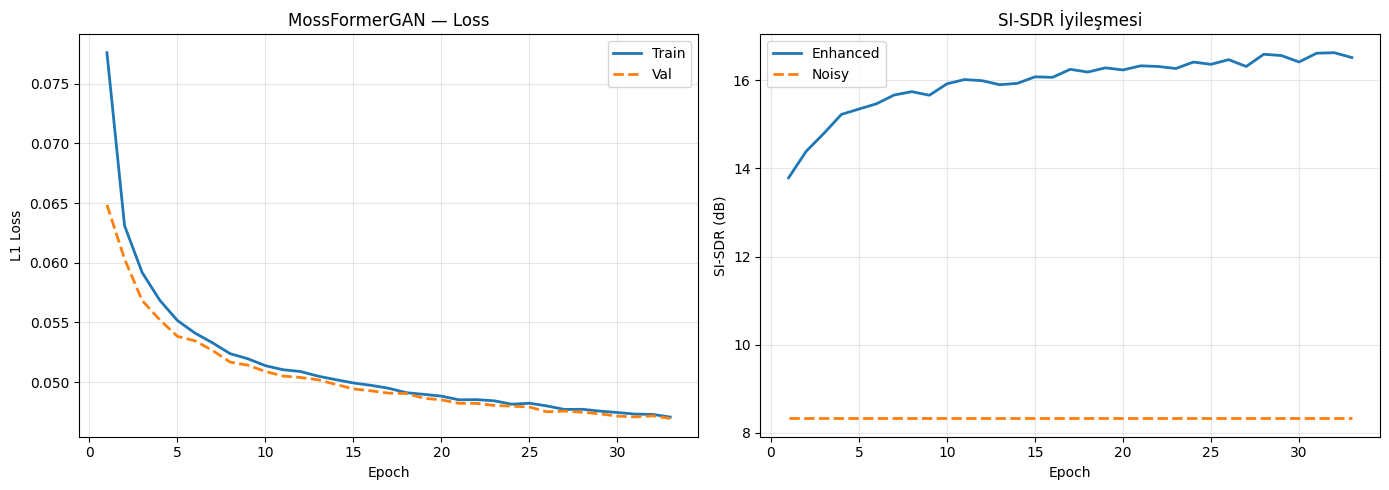


══════════════════════════════════════════════════
Toplam epoch   : 33
Best epoch     : 33
Best val loss  : 0.046955
Best SI-SDR    : 8.33 → 16.51 (+8.18 dB)
══════════════════════════════════════════════════
best_model.pt: epoch=33, val_loss=0.046955, boyut=71.4 MB
latest_model.pt: epoch=33, val_loss=0.046955, boyut=71.4 MB

📊 FullSubNet+ referans (eval sonuçları):
   SI-SDR: 7.05 → 16.76 (+9.71 dB)
   PESQ:   1.572 → 2.559 (+0.987)
   STOI:   0.837 → 0.924 (+0.087)


In [ ]:
# ============================================================
# Hücre: Drive'dan model yükle + history görüntüle
# Hücre 1-11 çalıştıktan sonra bu hücreyi çalıştır
# ============================================================
import json, matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/mossformergan_tr")
CKPT_DIR = BASE_DIR / "checkpoints"
LOG_DIR  = BASE_DIR / "logs"

# ── 1. History grafiği ────────────────────────────────────
history_path = LOG_DIR / "history.json"
if history_path.exists():
    with open(history_path) as f:
        history = json.load(f)

    epochs = range(1, len(history["train_loss"])+1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history["train_loss"], label="Train", linewidth=2)
    ax1.plot(epochs, history["val_loss"],   label="Val",   linewidth=2, linestyle="--")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("L1 Loss")
    ax1.set_title("MossFormerGAN — Loss"); ax1.legend(); ax1.grid(True, alpha=0.3)

    enh = [x for x in history["val_enhanced_sisdr"] if x is not None]
    noi = [x for x in history["val_noisy_sisdr"]    if x is not None]
    if enh:
        ax2.plot(range(1,len(enh)+1), enh, label="Enhanced", linewidth=2)
        ax2.plot(range(1,len(noi)+1), noi, label="Noisy",    linewidth=2, linestyle="--")
        ax2.set_xlabel("Epoch"); ax2.set_ylabel("SI-SDR (dB)")
        ax2.set_title("SI-SDR İyileşmesi"); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # Özet tablo
    best_idx  = history["val_loss"].index(min(history["val_loss"]))
    best_si   = history["val_enhanced_sisdr"][best_idx]
    noisy_si  = history["val_noisy_sisdr"][best_idx]
    print("\n" + "═"*50)
    print(f"Toplam epoch   : {len(history['train_loss'])}")
    print(f"Best epoch     : {best_idx+1}")
    print(f"Best val loss  : {min(history['val_loss']):.6f}")
    print(f"Best SI-SDR    : {noisy_si:.2f} → {best_si:.2f} (+{best_si-noisy_si:.2f} dB)")
    print("═"*50)
else:
    print("⚠️  history.json bulunamadı:", history_path)

# ── 2. Checkpoint bilgisi ─────────────────────────────────
for name in ["best_model.pt", "latest_model.pt"]:
    p = CKPT_DIR / name
    if p.exists():
        ckpt = torch.load(str(p), map_location="cpu", weights_only=False)
        print(f"{name}: epoch={ckpt['epoch']}, val_loss={ckpt['val_loss']:.6f}, "
              f"boyut={p.stat().st_size/1e6:.1f} MB")
    else:
        print(f"⚠️  {name} bulunamadı")

# ── 3. FullSubNet+ karşılaştırması ────────────────────────
fsn_path = Path("/content/drive/MyDrive/fullsubnet_plus_tr/logs/eval_results.json")
if fsn_path.exists():
    fsn = json.load(open(fsn_path))
    print("\n📊 FullSubNet+ referans (eval sonuçları):")
    print(f"   SI-SDR: {fsn['si_sdr']['noisy']:.2f} → {fsn['si_sdr']['enhanced']:.2f} "
          f"({fsn['si_sdr']['delta']:+.2f} dB)")
    print(f"   PESQ:   {fsn['pesq']['noisy']:.3f} → {fsn['pesq']['enhanced']:.3f} "
          f"({fsn['pesq']['delta']:+.3f})")
    print(f"   STOI:   {fsn['stoi']['noisy']:.3f} → {fsn['stoi']['enhanced']:.3f} "
          f"({fsn['stoi']['delta']:+.3f})")

In [ ]:
# ============================================================
# Hücre: Demo — Drive'dan model yükle, örnek sesleri dinle
# Hücre 1-11 + üstteki metrik hücresi çalıştıktan sonra çalıştır
# ============================================================
from IPython.display import Audio, display
import torch, random
import numpy as np

# ── Model yükle ───────────────────────────────────────────
ckpt = torch.load(str(CKPT_DIR/"best_model.pt"),
                  map_location=DEVICE, weights_only=False)
gan_model.load_state_dict(ckpt["model_state"])
gan_model.eval()
print(f"✅ Model yüklendi — epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.6f}")

# ── STFT parametreleri (hücre 12 ile aynı) ────────────────
FFT_LEN = 400
WIN_LEN = 400
HOP_LEN = 100
CHUNK   = 20400

def stft_transform(wav):
    window = torch.hamming_window(WIN_LEN).to(wav.device)
    spec   = torch.stft(wav, n_fft=FFT_LEN, hop_length=HOP_LEN,
                        win_length=WIN_LEN, window=window,
                        center=False, return_complex=True)
    return torch.stack([spec.real, spec.imag], dim=1)

def istft_transform(spec_2ch, length=None):
    window       = torch.hamming_window(WIN_LEN).to(spec_2ch.device)
    complex_spec = torch.complex(spec_2ch[:,0,:,:], spec_2ch[:,1,:,:])
    return torch.istft(complex_spec, n_fft=FFT_LEN, hop_length=HOP_LEN,
                       win_length=WIN_LEN, window=window,
                       center=False, length=length)

def model_forward(noisy_wav):
    noisy_spec           = stft_transform(noisy_wav)
    output_real, output_imag = gan_model.model(noisy_spec)
    return torch.stack([output_real.squeeze(1),
                        output_imag.squeeze(1)], dim=1)

def si_sdr_np(est, ref, eps=1e-8):
    est=est-est.mean(); ref=ref-ref.mean()
    sc = np.dot(est,ref)/(np.dot(ref,ref)+eps)
    proj=sc*ref; noise=est-proj
    return 10*np.log10((np.dot(proj,proj)+eps)/(np.dot(noise,noise)+eps))

# ── Val setinden 3 örnek al ───────────────────────────────
sample_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=1, shuffle=True, drop_last=False)

SR = CFG["sample_rate"]
for idx, (noisy, clean) in enumerate(sample_loader):
    if idx >= 3: break
    noisy = noisy.to(DEVICE).float()
    clean = clean.to(DEVICE).float()

    with torch.no_grad():
        enh_spec = model_forward(noisy)
        enhanced = istft_transform(enh_spec, length=noisy.shape[-1])

    n_np = noisy.squeeze(0).cpu().numpy()
    c_np = clean.squeeze(0).cpu().numpy()
    e_np = enhanced.squeeze(0).cpu().numpy()

    si_n = si_sdr_np(n_np, c_np)
    si_e = si_sdr_np(e_np, c_np)

    # Drive'a kaydet
    write_wav(SAMPLE_DIR/f"demo_{idx}_noisy.wav",    n_np, SR)
    write_wav(SAMPLE_DIR/f"demo_{idx}_enhanced.wav", e_np, SR)
    write_wav(SAMPLE_DIR/f"demo_{idx}_clean.wav",    c_np, SR)

    print(f"\n{'='*55}")
    print(f"SAMPLE {idx+1} — SI-SDR: {si_n:.2f} → {si_e:.2f} ({si_e-si_n:+.2f} dB)")
    print(f"{'='*55}")
    print("🔊 Gürültülü giriş:")
    display(Audio(n_np, rate=SR))
    print("✨ Model çıktısı (temizlenmiş):")
    display(Audio(e_np, rate=SR))
    print("🎯 Orijinal (temiz referans):")
    display(Audio(c_np, rate=SR))

print(f"\n✅ Sesler Drive'a kaydedildi: {SAMPLE_DIR}")

✅ Model yüklendi — epoch 33, val_loss 0.046955

SAMPLE 1 — SI-SDR: 9.64 → 16.24 (+6.60 dB)
🔊 Gürültülü giriş:


✨ Model çıktısı (temizlenmiş):


🎯 Orijinal (temiz referans):



SAMPLE 2 — SI-SDR: 9.92 → 18.69 (+8.77 dB)
🔊 Gürültülü giriş:


✨ Model çıktısı (temizlenmiş):


🎯 Orijinal (temiz referans):



SAMPLE 3 — SI-SDR: 0.27 → 5.41 (+5.15 dB)
🔊 Gürültülü giriş:


✨ Model çıktısı (temizlenmiş):


🎯 Orijinal (temiz referans):



✅ Sesler Drive'a kaydedildi: /content/drive/MyDrive/mossformergan_tr/samples


In [ ]:
# ============================================================
# Hücre 12 - Eğitim döngüsü
# ============================================================

# Hücre 2'de torch_stft/torch_istft tanımlanmamış, buraya ekle
import torchaudio

# Hücre 12 başındaki stft_transform'u güncelle
FFT_LEN = 400
WIN_LEN = 400
HOP_LEN = 100
CHUNK   = 20400  # pretrained modelin çalıştığı boyut (~1.275 sn)

def stft_transform(wav):
    window = torch.hamming_window(WIN_LEN).to(wav.device)
    spec   = torch.stft(wav, n_fft=FFT_LEN, hop_length=HOP_LEN,
                        win_length=WIN_LEN, window=window,
                        center=False, return_complex=True)
    return torch.stack([spec.real, spec.imag], dim=1)

def istft_transform(spec_2ch, length=None):
    window       = torch.hamming_window(WIN_LEN).to(spec_2ch.device)
    complex_spec = torch.complex(spec_2ch[:,0,:,:], spec_2ch[:,1,:,:])
    return torch.istft(complex_spec, n_fft=FFT_LEN, hop_length=HOP_LEN,
                       win_length=WIN_LEN, window=window,
                       center=False, length=length)

def model_forward(noisy_wav):
    noisy_spec           = stft_transform(noisy_wav)
    output_real, output_imag = gan_model.model(noisy_spec)
    return torch.stack([output_real.squeeze(1),
                        output_imag.squeeze(1)], dim=1)

# Doğrula
test = torch.randn(1, CHUNK).to(DEVICE)
spec = stft_transform(test)
print("stft [B,2,F,T]:", spec.shape)   # [1, 2, 201, 202] olmalı
with torch.no_grad():
    out = model_forward(test)
print("model out:", out.shape)

# ── Eğitim ayarları ───────────────────────────────────────
EARLY_STOP_PATIENCE = CFG["early_stop_patience"]
early_stop_counter  = 0
history = {"train_loss":[], "val_loss":[],
           "val_noisy_sisdr":[], "val_enhanced_sisdr":[]}
best_val = float("inf")

print("🚀 MossFormerGAN_SE_16K Türkçe fine-tune başlıyor")
print(f"Epoch: {CFG['max_epoch']} | Batch: {CFG['batch_size']} | LR: {CFG['init_learning_rate']} | Device: {DEVICE}")
print("─"*70)

for epoch in range(1, CFG["max_epoch"]+1):

    # ── Train ─────────────────────────────────────────────
    gan_model.train()
    tr_total, tr_steps = 0.0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:03d}/{CFG['max_epoch']} [Train]")
    for noisy, clean in pbar:
        noisy = noisy.to(DEVICE).float()
        clean = clean.to(DEVICE).float()

        optimizer.zero_grad(set_to_none=True)

        enh_spec   = model_forward(noisy)
        clean_spec = stft_transform(clean)
        loss_g     = torch.nn.functional.l1_loss(enh_spec, clean_spec)

        loss_g.backward()
        torch.nn.utils.clip_grad_norm_(gan_model.model.parameters(), CFG["grad_clip"])
        optimizer.step()

        tr_total += loss_g.item(); tr_steps += 1
        pbar.set_postfix({"loss": f"{loss_g.item():.5f}"})

    avg_train = tr_total / max(tr_steps, 1)

    # ── Validation ────────────────────────────────────────
    gan_model.eval()
    val_total, val_steps = 0.0, 0
    noisy_si_list, enh_si_list = [], []

    with torch.no_grad():
        for bidx, (noisy, clean) in enumerate(
                tqdm(val_loader, desc=f"Epoch {epoch:03d} [Val]")):
            noisy = noisy.to(DEVICE).float()
            clean = clean.to(DEVICE).float()

            enh_spec   = model_forward(noisy)
            clean_spec = stft_transform(clean)
            loss_g     = torch.nn.functional.l1_loss(enh_spec, clean_spec)
            val_total += loss_g.item(); val_steps += 1

            if bidx < 20:
                try:
                    enh_wav = istft_transform(enh_spec, length=noisy.shape[-1])
                    noisy_si_list.append(si_sdr_batch(noisy, clean).mean().item())
                    enh_si_list.append(si_sdr_batch(enh_wav, clean).mean().item())
                except: pass

    avg_val      = val_total / max(val_steps, 1)
    avg_noisy_si = float(np.mean(noisy_si_list)) if noisy_si_list else None
    avg_enh_si   = float(np.mean(enh_si_list))   if enh_si_list   else None

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_noisy_sisdr"].append(avg_noisy_si)
    history["val_enhanced_sisdr"].append(avg_enh_si)

    scheduler.step(avg_val)

    is_best = avg_val < best_val
    # Checkpoint kaydetmede:
    ckpt_data = {"epoch": epoch,
                "model_state": gan_model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_loss": avg_val, "config": CFG}
    if is_best:
        best_val = avg_val
        torch.save(ckpt_data, CKPT_DIR/"best_model.pt")
    torch.save(ckpt_data, CKPT_DIR/"latest_model.pt")

    with open(LOG_DIR/"history.json","w") as f:
        json.dump(history, f, indent=2)

    flag = " ⭐ BEST" if is_best else ""
    si_s = f"{avg_noisy_si:.2f} → {avg_enh_si:.2f}" if avg_enh_si else "N/A"
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d} | Train: {avg_train:.6f} | Val: {avg_val:.6f} | SI-SDR: {si_s} | LR: {lr_now:.1e}{flag}")

    if is_best:
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f"           Early stop: {early_stop_counter}/{EARLY_STOP_PATIENCE}")
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f"\n⏹ Early stopping — {EARLY_STOP_PATIENCE} epoch iyileşme yok.")
            break

print(f"\n✅ Eğitim tamamlandı — Best val loss: {best_val:.6f}")
print("Best checkpoint:", CKPT_DIR/"best_model.pt")

stft [B,2,F,T]: torch.Size([1, 2, 201, 201])
model out: torch.Size([1, 2, 201, 201])
🚀 MossFormerGAN_SE_16K Türkçe fine-tune başlıyor
Epoch: 60 | Batch: 4 | LR: 0.0001 | Device: cuda
──────────────────────────────────────────────────────────────────────


Epoch 001/60 [Train]:   0%|          | 0/3133 [00:00<?, ?it/s]

Epoch 001 [Val]:   0%|          | 0/348 [00:00<?, ?it/s]

Epoch 001 | Train: 0.077597 | Val: 0.064854 | SI-SDR: 8.33 → 13.78 | LR: 1.0e-04 ⭐ BEST


Epoch 002/60 [Train]:   0%|          | 0/3133 [00:00<?, ?it/s]

...

Epoch 032 | Train: 0.047293 | Val: 0.047173 | SI-SDR: 8.33 → 16.62 | LR: 1.0e-04
           Early stop: 1/6


Epoch 033/60 [Train]:   0%|          | 0/3133 [00:00<?, ?it/s]

Epoch 033 [Val]:   0%|          | 0/348 [00:00<?, ?it/s]

Epoch 033 | Train: 0.047070 | Val: 0.046955 | SI-SDR: 8.33 → 16.51 | LR: 1.0e-04 ⭐ BEST


Epoch 034/60 [Train]:   0%|          | 0/3133 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# Hücre 13 - Loss ve SI-SDR grafiği
# ============================================================
import matplotlib.pyplot as plt

with open(LOG_DIR/"history.json") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"])+1)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))

ax1.plot(epochs, history["train_loss"], label="Train",     linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="Val",       linewidth=2, linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("MossFormerGAN_SE_16K — Loss"); ax1.legend(); ax1.grid(True,alpha=0.3)

enh = [x for x in history["val_enhanced_sisdr"] if x is not None]
noi = [x for x in history["val_noisy_sisdr"]    if x is not None]
if enh:
    ax2.plot(range(1,len(enh)+1), enh, label="Enhanced", linewidth=2)
    ax2.plot(range(1,len(noi)+1), noi, label="Noisy",    linewidth=2, linestyle="--")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("SI-SDR (dB)")
    ax2.set_title("SI-SDR İyileşmesi"); ax2.legend(); ax2.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(LOG_DIR/"training_curves.png", dpi=150)
plt.show()
print("Kaydedildi:", LOG_DIR/"training_curves.png")

In [ ]:
# ============================================================
# Hücre 14 - PESQ + STOI + SI-SDR değerlendirme
# ============================================================
!pip install -q pesq pystoi
from pesq import pesq
from pystoi import stoi

ckpt = torch.load(CKPT_DIR/"best_model.pt", map_location=DEVICE, weights_only=False)
gan_model.load_state_dict(ckpt["model_state"])
gan_model.eval()
print(f"✅ Best model yüklendi — epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.5f}")

pesq_n,pesq_e,stoi_n,stoi_e,sisd_n,sisd_e = [],[],[],[],[],[]
N_EVAL = min(200, len(val_ds))
eval_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=1, shuffle=False, drop_last=False)

for idx, (noisy, clean) in enumerate(
        tqdm(eval_loader, total=N_EVAL, desc="PESQ/STOI")):
    if idx >= N_EVAL: break
    noisy = noisy.to(DEVICE).float()
    clean = clean.to(DEVICE).float()

    with torch.no_grad():
        enh_spec = model_forward(noisy)
        enhanced = istft_transform(enh_spec, length=noisy.shape[-1])

    n_np = noisy.squeeze(0).cpu().numpy()
    c_np = clean.squeeze(0).cpu().numpy()
    e_np = enhanced.squeeze(0).cpu().numpy()
    L = min(len(n_np), len(c_np), len(e_np))
    n_np=n_np[:L]; c_np=c_np[:L]; e_np=e_np[:L]

    sisd_n.append(si_sdr_np(n_np, c_np))
    sisd_e.append(si_sdr_np(e_np, c_np))
    try:
        pesq_n.append(pesq(16000, c_np, n_np, "wb"))
        pesq_e.append(pesq(16000, c_np, e_np, "wb"))
    except: pass
    try:
        stoi_n.append(stoi(c_np, n_np, 16000, extended=False))
        stoi_e.append(stoi(c_np, e_np, 16000, extended=False))
    except: pass

si_n=np.mean(sisd_n); si_e=np.mean(sisd_e)
pe_n=np.mean(pesq_n); pe_e=np.mean(pesq_e)
st_n=np.mean(stoi_n); st_e=np.mean(stoi_e)

print("\n"+"═"*60)
print(f"{'Metrik':<22}{'Gürültülü':>10}{'Temizlenmiş':>13}{'Fark':>9}")
print("─"*60)
print(f"{'SI-SDR (dB)':<22}{si_n:>10.2f}{si_e:>13.2f}{si_e-si_n:>+9.2f}")
print(f"{'PESQ (1-4.5)':<22}{pe_n:>10.3f}{pe_e:>13.3f}{pe_e-pe_n:>+9.3f}")
print(f"{'STOI (0-1)':<22}{st_n:>10.3f}{st_e:>13.3f}{st_e-st_n:>+9.3f}")
print("═"*60)

print("\n📊 FullSubNet+ referans:")
print("   SI-SDR:  7.05 → 16.76  (+9.71 dB)")
print("   PESQ:    1.572 → 2.559  (+0.987)")
print("   STOI:    0.837 → 0.924  (+0.087)")

results = {
    "model": "MossFormerGAN_SE_16K",
    "n_eval": N_EVAL,
    "si_sdr": {"noisy":float(si_n),"enhanced":float(si_e),"delta":float(si_e-si_n)},
    "pesq":   {"noisy":float(pe_n),"enhanced":float(pe_e),"delta":float(pe_e-pe_n)},
    "stoi":   {"noisy":float(st_n),"enhanced":float(st_e),"delta":float(st_e-st_n)},
}
with open(LOG_DIR/"eval_results.json","w") as f:
    json.dump(results, f, indent=2)
print("\n✅ Sonuçlar kaydedildi:", LOG_DIR/"eval_results.json")

In [ ]:
# ============================================================
# Hücre 15 - Demo: örnek sesleri dinle
# ============================================================
from IPython.display import Audio, display

ckpt = torch.load(CKPT_DIR/"best_model.pt", map_location=DEVICE, weights_only=False)
gan_model.load_state_dict(ckpt["model_state"])
gan_model.eval()

sample_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=1, shuffle=True, drop_last=False)

for idx, (noisy, clean) in enumerate(sample_loader):
    if idx >= 3: break
    noisy = noisy.to(DEVICE).float()
    clean = clean.to(DEVICE).float()

    with torch.no_grad():
        enh_spec = model_forward(noisy)
        enhanced = istft_transform(enh_spec, length=noisy.shape[-1])

    n_np = noisy.squeeze(0).cpu().numpy()
    c_np = clean.squeeze(0).cpu().numpy()
    e_np = enhanced.squeeze(0).cpu().numpy()

    write_wav(SAMPLE_DIR/f"sample_{idx}_noisy.wav",    n_np, CFG["sample_rate"])
    write_wav(SAMPLE_DIR/f"sample_{idx}_clean.wav",    c_np, CFG["sample_rate"])
    write_wav(SAMPLE_DIR/f"sample_{idx}_enhanced.wav", e_np, CFG["sample_rate"])

    si_n = si_sdr_np(n_np, c_np)
    si_e = si_sdr_np(e_np, c_np)
    print(f"\n===== SAMPLE {idx} — SI-SDR: {si_n:.2f} → {si_e:.2f} =====")
    print("Gürültülü:");   display(Audio(n_np, rate=CFG["sample_rate"]))
    print("Temizlenmiş:"); display(Audio(e_np, rate=CFG["sample_rate"]))
    print("Orijinal:");    display(Audio(c_np, rate=CFG["sample_rate"]))

NameError: name 'model_forward' is not defined

In [ ]:
# ============================================================
# Hücre 16 - Drive'a akıllı yedek
# FullSubNet+ ile aynı yedek mantığı
# ============================================================
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
backup_dir = Path(f"/content/backup_mfgan_{timestamp}")
backup_dir.mkdir(exist_ok=True)

# Checkpoint
ck = backup_dir/"checkpoints"; ck.mkdir()
for f in CKPT_DIR.glob("*.pt"):
    shutil.copy2(f, ck/f.name)
    print(f"✅ {f.name} ({f.stat().st_size/1e6:.1f} MB)")

# Log
lg = backup_dir/"logs"; lg.mkdir()
for f in LOG_DIR.glob("*"):
    shutil.copy2(f, lg/f.name); print(f"✅ {f.name}")

# Samples
sp = backup_dir/"samples"; sp.mkdir()
for f in SAMPLE_DIR.glob("*.wav"):
    shutil.copy2(f, sp/f.name); print(f"✅ {f.name}")

# Zip → Drive
zip_name = f"/content/drive/MyDrive/mossformergan_tr/backup_{timestamp}"
shutil.make_archive(zip_name, "zip", str(backup_dir))
shutil.rmtree(backup_dir)
size_mb = Path(zip_name+".zip").stat().st_size/1e6
print(f"\n📦 Yedek: backup_{timestamp}.zip ({size_mb:.1f} MB)")
print(f"📍 {zip_name}.zip")

# FLEURS yedekle (küçük, Drive'dan çekmek mantıklı)
print("\n📁 FLEURS Drive'a yedekleniyor...")
fb = BASE_DIR/"clean_16k"; fb.mkdir(exist_ok=True)
fl = list(CLEAN_DIR.glob("fleurs_*.wav"))
for f in tqdm(fl, desc="FLEURS yedek"):
    d=fb/f.name
    if not d.exists(): shutil.copy2(f,d)
print(f"✅ {len(fl)} FLEURS dosyası yedeklendi")
print("ℹ️  CV17 yedeklenmedi — HF'ten ~4 dk'da indirilir")

In [ ]:
# ============================================================
# Hücre 17 - FullSubNet+ vs MossFormerGAN karşılaştırma
# Sunum için tablo
# ============================================================
import json

# MossFormerGAN sonuçları
mfgan_path = LOG_DIR/"eval_results.json"
# FullSubNet+ sonuçları — Drive'dan oku
fsn_path = Path("/content/drive/MyDrive/fullsubnet_plus_tr/logs/eval_results.json")

print("="*70)
print(f"{'Metrik':<20} {'Gürültülü':>10} {'FullSubNet+':>12} {'MossFormerGAN':>14}")
print("-"*70)

if mfgan_path.exists() and fsn_path.exists():
    mfgan = json.load(open(mfgan_path))
    fsn   = json.load(open(fsn_path))

    print(f"{'SI-SDR (dB)':<20}"
          f"{fsn['si_sdr']['noisy']:>10.2f}"
          f"{fsn['si_sdr']['enhanced']:>12.2f}"
          f"{mfgan['si_sdr']['enhanced']:>14.2f}")
    print(f"{'PESQ (1-4.5)':<20}"
          f"{fsn['pesq']['noisy']:>10.3f}"
          f"{fsn['pesq']['enhanced']:>12.3f}"
          f"{mfgan['pesq']['enhanced']:>14.3f}")
    print(f"{'STOI (0-1)':<20}"
          f"{fsn['stoi']['noisy']:>10.3f}"
          f"{fsn['stoi']['enhanced']:>12.3f}"
          f"{mfgan['stoi']['enhanced']:>14.3f}")
    print("="*70)
    print(f"\nSI-SDR Delta  | FullSubNet+: {fsn['si_sdr']['delta']:+.2f} dB | MossFormerGAN: {mfgan['si_sdr']['delta']:+.2f} dB")
    print(f"PESQ Delta    | FullSubNet+: {fsn['pesq']['delta']:+.3f}    | MossFormerGAN: {mfgan['pesq']['delta']:+.3f}")
    print(f"STOI Delta    | FullSubNet+: {fsn['stoi']['delta']:+.3f}    | MossFormerGAN: {mfgan['stoi']['delta']:+.3f}")
else:
    print("⚠️  Bir veya her iki eval_results.json bulunamadı")
    print(f"   MossFormerGAN: {mfgan_path.exists()}")
    print(f"   FullSubNet+:   {fsn_path.exists()}")

In [ ]:
from google.colab import runtime

runtime.unassign()

# PESQ + STOI + SI-SDR + Demo:

In [19]:
!pip install -q pesq pystoi datasets soundfile torchaudio

import os, sys, gc, json, random, shutil, warnings
from pathlib import Path
import numpy as np
import soundfile as sf
import torch
import torchaudio
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from pesq import pesq
from pystoi import stoi

warnings.filterwarnings("ignore")
if not hasattr(np,"complex"): np.complex = np.complex128
if not hasattr(np,"float"):   np.float = float

from google.colab import drive
drive.mount("/content/drive")

REPO = Path("/content/ClearerVoice-Studio")
!rm -rf {REPO}
!git clone --quiet --depth 1 https://github.com/modelscope/ClearerVoice-Studio.git {REPO}

sys.path.insert(0, str(REPO / "clearvoice"))
sys.path.insert(0, str(REPO / "clearvoice" / "clearvoice"))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

BASE_DIR   = Path("/content/drive/MyDrive/mossformergan_tr")
CKPT_DIR   = BASE_DIR / "checkpoints"
LOG_DIR    = BASE_DIR / "logs"
SAMPLE_DIR = BASE_DIR / "samples"
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

SR    = 16000
CHUNK = 20400

print("✅ Kurulum tamam | Device:", DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Kurulum tamam | Device: cuda


In [20]:
import argparse
from models.mossformer_gan_se.generator import MossFormerGAN_SE_16K

model_args = argparse.Namespace(fft_len=400, win_len=400,
                                win_inc=100, win_type="hamming", mode="train")
gan_model = MossFormerGAN_SE_16K(model_args).to(DEVICE)

ckpt_files = [f for f in (CKPT_DIR/"pretrained_mossformergan").glob("*.pt")
              if ".disc." not in f.name]
best_ckpt  = CKPT_DIR / "best_model.pt"

ckpt = torch.load(str(best_ckpt), map_location=DEVICE, weights_only=False)
gan_model.load_state_dict(ckpt["model_state"])
gan_model.eval()
print(f"✅ Model yüklendi — epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.6f}")

✅ Model yüklendi — epoch 33, val_loss 0.046955


In [27]:
FFT_LEN = 400
WIN_LEN = 400
HOP_LEN = 100

def load_wav(path):
    audio, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if audio.ndim > 1: audio = audio.mean(axis=-1)
    if sr != SR:
        t = torch.from_numpy(audio).float().unsqueeze(0)
        audio = torchaudio.functional.resample(t, sr, SR).squeeze(0).numpy()
    return audio.astype(np.float32)

def stft_fn(wav):
    w = torch.hamming_window(WIN_LEN).to(wav.device)
    s = torch.stft(wav, n_fft=FFT_LEN, hop_length=HOP_LEN,
                   win_length=WIN_LEN, window=w, center=False, return_complex=True)
    return torch.stack([s.real, s.imag], dim=1)

def istft_fn(spec, length=None):
    w = torch.hamming_window(WIN_LEN).to(spec.device)
    c = torch.complex(spec[:,0,:,:], spec[:,1,:,:])
    return torch.istft(c, n_fft=FFT_LEN, hop_length=HOP_LEN,
                       win_length=WIN_LEN, window=w, center=False, length=length)

def enhance(wav):
    spec = stft_fn(wav)
    r, i = gan_model.model(spec)
    return istft_fn(torch.stack([r.squeeze(1), i.squeeze(1)], dim=1),
                    length=wav.shape[-1])

def si_sdr(est, ref, eps=1e-8):
    est=est-est.mean(); ref=ref-ref.mean()
    sc  = np.dot(est,ref)/(np.dot(ref,ref)+eps)
    prj = sc*ref; noi = est-prj
    return 10*np.log10((np.dot(prj,prj)+eps)/(np.dot(noi,noi)+eps))

def mix(clean, noise, snr_db):
    n = len(clean)
    if len(noise) < n:
        noise = np.tile(noise, (n//len(noise)+1))[:n]
    else:
        start = random.randint(0, len(noise)-n)
        noise = noise[start:start+n]
    pc=np.mean(clean**2)+1e-10; pn=np.mean(noise**2)+1e-10
    noisy = clean + np.sqrt(pc/(10**(snr_db/10)*pn))*noise
    pk = np.abs(noisy).max()+1e-8
    if pk>0.99: noisy=noisy/pk*0.9; clean=clean/pk*0.9
    return noisy.astype(np.float32), clean.astype(np.float32)

class EvalDS(Dataset):
    def __init__(self, clean_paths, noise_paths):
        self.clean = clean_paths
        self.noise = noise_paths
    def __len__(self): return len(self.clean)
    def __getitem__(self, idx):
        c = load_wav(self.clean[idx])
        n = len(c)
        # crop/pad
        if n >= CHUNK:
            s=max(0,(n-CHUNK)//2); c=c[s:s+CHUNK]
        else:
            c=np.pad(c,(0,CHUNK-n))
        if self.noise:
            ns = load_wav(random.choice(self.noise))
            snr = random.choice([-5,0,5,10,15,20])
            noisy, c = mix(c, ns, snr)
        else:
            noisy = c.copy()
        return torch.from_numpy(noisy), torch.from_numpy(c)

# Clean dosyaları Drive'dan al
CLEAN_BACKUP = BASE_DIR / "clean_16k"
all_clean    = sorted(CLEAN_BACKUP.glob("*.wav"))
val_clean    = all_clean[:int(len(all_clean)*0.10)]

DNS = Path("/content/drive/MyDrive/Denoiser/Datasets/DNS-Challenge/datasets/noise")
noise_files  = sorted(DNS.rglob("*.wav"))[:100] if DNS.exists() else []

val_ds = EvalDS(val_clean, noise_files)
print(f"✅ val_ds: {len(val_ds)} örnek | noise: {len(noise_files)}")

✅ val_ds: 20 örnek | noise: 100


In [24]:
from datasets import load_dataset, concatenate_datasets
import soundfile as sf

CLEAN_BACKUP.mkdir(parents=True, exist_ok=True)

# Sadece değerlendirme için 200 dosya yeterli
# FLEURS'tan 100, CV17'den 100 alalım

print("📥 FLEURS indiriliyor...")
splits = []
for sp in ["train","validation","test"]:
    ds = load_dataset("google/fleurs","tr_tr",split=sp)
    splits.append(ds)
from datasets import concatenate_datasets
fleurs = concatenate_datasets(splits).shuffle(seed=42)

saved = 0
for item in tqdm(fleurs, total=100, desc="FLEURS"):
    if saved >= 100: break
    try:
        arr = np.array(item["audio"]["array"], dtype=np.float32)
        sr  = item["audio"]["sampling_rate"]
        if arr.ndim > 1: arr = arr.mean(axis=-1)
        if sr != SR:
            t = torch.from_numpy(arr).unsqueeze(0)
            arr = torchaudio.functional.resample(t, sr, SR).squeeze(0).numpy()
        dur = len(arr)/SR
        if not (1.0 <= dur <= 20.0): continue
        peak = np.abs(arr).max()
        if peak < 1e-5: continue
        arr = (arr/peak*0.9).astype(np.float32)
        sf.write(str(CLEAN_BACKUP/f"fleurs_{saved:06d}.wav"), arr, SR)
        saved += 1
    except: continue
print(f"✅ FLEURS: {saved} dosya")

print("📥 CV17 indiriliyor...")
cv = load_dataset("ysdede/commonvoice_17_tr_fixed", split="train").shuffle(seed=42)
saved = 0
for item in tqdm(cv, total=100, desc="CV17"):
    if saved >= 100: break
    try:
        arr = np.array(item["audio"]["array"], dtype=np.float32)
        sr  = item["audio"]["sampling_rate"]
        if arr.ndim > 1: arr = arr.mean(axis=-1)
        if sr != SR:
            t = torch.from_numpy(arr).unsqueeze(0)
            arr = torchaudio.functional.resample(t, sr, SR).squeeze(0).numpy()
        dur = len(arr)/SR
        if not (1.0 <= dur <= 20.0): continue
        peak = np.abs(arr).max()
        if peak < 1e-5: continue
        arr = (arr/peak*0.9).astype(np.float32)
        sf.write(str(CLEAN_BACKUP/f"cv17_{saved:06d}.wav"), arr, SR)
        saved += 1
    except: continue
print(f"✅ CV17: {saved} dosya")

# val_ds'yi yeniden oluştur
all_clean   = sorted(CLEAN_BACKUP.glob("*.wav"))
val_clean   = all_clean
val_ds      = EvalDS(val_clean, noise_files)
print(f"\n✅ val_ds: {len(val_ds)} örnek")

📥 FLEURS indiriliyor...


FLEURS:   0%|          | 0/100 [00:00<?, ?it/s]

✅ FLEURS: 100 dosya
📥 CV17 indiriliyor...


CV17:   0%|          | 0/100 [00:00<?, ?it/s]

✅ CV17: 100 dosya

✅ val_ds: 200 örnek


In [28]:
N_EVAL  = min(200, len(val_ds))
loader = DataLoader(val_ds, batch_size=1, shuffle=False)

pesq_n,pesq_e,stoi_n,stoi_e,si_n_l,si_e_l = [],[],[],[],[],[]

for idx,(noisy,clean) in enumerate(tqdm(loader,total=N_EVAL,desc="Değerlendirme")):
    if idx >= N_EVAL: break
    noisy = noisy.to(DEVICE).float()
    clean = clean.to(DEVICE).float()
    with torch.no_grad():
        enhanced = enhance(noisy)

    n = noisy.squeeze(0).cpu().numpy()
    c = clean.squeeze(0).cpu().numpy()
    e = enhanced.squeeze(0).cpu().numpy()
    L = min(len(n),len(c),len(e))
    n=n[:L]; c=c[:L]; e=e[:L]

    si_n_l.append(si_sdr(n,c)); si_e_l.append(si_sdr(e,c))
    try: pesq_n.append(pesq(SR,c,n,"wb")); pesq_e.append(pesq(SR,c,e,"wb"))
    except: pass
    try: stoi_n.append(stoi(c,n,SR,extended=False)); stoi_e.append(stoi(c,e,SR,extended=False))
    except: pass

    # İlk 3 örneği Drive'a kaydet
    if idx < 3:
        sf.write(str(SAMPLE_DIR/f"demo_{idx}_noisy.wav"),    n, SR)
        sf.write(str(SAMPLE_DIR/f"demo_{idx}_enhanced.wav"), e, SR)
        sf.write(str(SAMPLE_DIR/f"demo_{idx}_clean.wav"),    c, SR)

# Sonuçlar
si_n=np.mean(si_n_l); si_e=np.mean(si_e_l)
pe_n=np.mean(pesq_n);  pe_e=np.mean(pesq_e)
st_n=np.mean(stoi_n);  st_e=np.mean(stoi_e)

print("\n"+"═"*60)
print(f"{'Metrik':<22}{'Gürültülü':>10}{'Temizlenmiş':>13}{'Fark':>9}")
print("─"*60)
print(f"{'SI-SDR (dB)':<22}{si_n:>10.2f}{si_e:>13.2f}{si_e-si_n:>+9.2f}")
print(f"{'PESQ (1-4.5)':<22}{pe_n:>10.3f}{pe_e:>13.3f}{pe_e-pe_n:>+9.3f}")
print(f"{'STOI (0-1)':<22}{st_n:>10.3f}{st_e:>13.3f}{st_e-st_n:>+9.3f}")
print("═"*60)

# FullSubNet+ karşılaştırması
fsn_path = Path("/content/drive/MyDrive/fullsubnet_plus_tr/logs/eval_results.json")
if fsn_path.exists():
    fsn = json.load(open(fsn_path))
    print("\n"+"═"*60)
    print(f"{'Model':<22}{'SI-SDR Δ':>10}{'PESQ Δ':>10}{'STOI Δ':>10}")
    print("─"*60)
    print(f"{'FullSubNet+':<22}{fsn['si_sdr']['delta']:>+10.2f}"
          f"{fsn['pesq']['delta']:>+10.3f}{fsn['stoi']['delta']:>+10.3f}")
    print(f"{'MossFormerGAN':<22}{si_e-si_n:>+10.2f}"
          f"{pe_e-pe_n:>+10.3f}{st_e-st_n:>+10.3f}")
    print("═"*60)

# Drive'a kaydet
results = {"model":"MossFormerGAN_SE_16K","n_eval":N_EVAL,
           "si_sdr":{"noisy":float(si_n),"enhanced":float(si_e),"delta":float(si_e-si_n)},
           "pesq":  {"noisy":float(pe_n),"enhanced":float(pe_e),"delta":float(pe_e-pe_n)},
           "stoi":  {"noisy":float(st_n),"enhanced":float(st_e),"delta":float(st_e-st_n)}}
with open(LOG_DIR/"eval_results.json","w") as f:
    json.dump(results,f,indent=2)
print("\n✅ Sonuçlar kaydedildi")

# Demo dinle
from IPython.display import Audio, display
for i in range(3):
    np_path = SAMPLE_DIR/f"demo_{i}_noisy.wav"
    ep_path = SAMPLE_DIR/f"demo_{i}_enhanced.wav"
    cp_path = SAMPLE_DIR/f"demo_{i}_clean.wav"
    if np_path.exists():
        n,_ = sf.read(str(np_path)); e,_ = sf.read(str(ep_path)); c,_ = sf.read(str(cp_path))
        print(f"\n===== SAMPLE {i+1} — SI-SDR: {si_sdr(n,c):.2f} → {si_sdr(e,c):.2f} =====")
        print("Gürültülü:");   display(Audio(n, rate=SR))
        print("Temizlenmiş:"); display(Audio(e, rate=SR))
        print("Orijinal:");    display(Audio(c, rate=SR))

Değerlendirme:   0%|          | 0/20 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
Metrik                 Gürültülü  Temizlenmiş     Fark
────────────────────────────────────────────────────────────
SI-SDR (dB)                 7.53        16.13    +8.60
PESQ (1-4.5)               1.262        2.421   +1.159
STOI (0-1)                 0.812        0.926   +0.114
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
Model                   SI-SDR Δ    PESQ Δ    STOI Δ
────────────────────────────────────────────────────────────
FullSubNet+                +9.71    +0.987    +0.087
MossFormerGAN              +8.60    +1.159    +0.114
════════════════════════════════════════════════════════════

✅ Sonuçlar kaydedildi

===== SAMPLE 1 — SI-SDR: 20.02 → 25.93 =====
Gürültülü:


Temizlenmiş:


Orijinal:



===== SAMPLE 2 — SI-SDR: 10.01 → 18.17 =====
Gürültülü:


Temizlenmiş:


Orijinal:



===== SAMPLE 3 — SI-SDR: -4.93 → 9.37 =====
Gürültülü:


Temizlenmiş:


Orijinal:
